In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from classification_utils_GLV import *
from classification_utils_replicator import *
from formalism import *

In [3]:
types_replicator = {
    "saturated": ("saturated", True),
    "stable": ("stable", True),
    "ESS": ("ESS", True)
}

In [4]:
types_glv = {
    "saturated": ("saturated", True),
    "stable": ("stable", True)
}

In [5]:
def compute_and_save_results(
    M,
    filename,
    generate_params,
    classification,
    types,
    N=10,
    variable=None,         # eg: "mu", "sigma", "c"
    values=None,           # list for 1D variation
    grid_variables=None,   # eg: ("c", "sigma")
    grid_values=None,      # eg: (c_values, sigma_values)
    fixed_params=None,
    tol=1e-6
):
    """
    One function for :
    - Random case (aucune variation),
    - Variation 1D,
    - Grid 2D.
    """

    if fixed_params is None:
        fixed_params = {}

    results = {}

    # Random case

    if variable is None and grid_variables is None:
        print("Random case")

        def gen():
            return generate_params(N, **fixed_params)

        P_type, S, histo = monte_carlo_full(
            M=M,
            N=N,
            generate_params=gen,
            classification=lambda params: classification(params, tol=tol),
            types=types
        )

        results["random"] = {
            "P_type": P_type,
            "S": S,
            "histo": histo
        }

        with open(filename, "wb") as f:
            pickle.dump(results, f)

        return results

    # Case 1D: one parameter varies 

    if variable is not None:
        for val in values:
            print(f"{variable} = {val}")

            params = fixed_params.copy()
            params[variable] = val

            def gen(params=params):
                return generate_params(N, **params)

            P_type, S, histo = monte_carlo_full(
                M=M,
                N=N,
                generate_params=gen,
                classification=lambda params_: classification(params_, tol=tol),
                types=types
            )

            results[val] = {
                "P_type": P_type,
                "S": S,
                "histo": histo
            }

            with open(filename, "wb") as f:
                pickle.dump(results, f)

        return results

    # Case 2D: grid on two parameters

    if grid_variables is not None:
        var1, var2 = grid_variables
        vals1, vals2 = grid_values

        for v1 in vals1:
            for v2 in vals2:
                print(f"{var1} = {v1}, {var2} = {v2}")

                params = fixed_params.copy()
                params[var1] = v1
                params[var2] = v2

                def gen(params=params):
                    return generate_params(N, **params)

                P_type, S, histo = monte_carlo_full(
                    M=M,
                    N=N,
                    generate_params=gen,
                    classification=lambda params_: classification(params_, tol=tol),
                    types=types
                )

                results[(v1, v2)] = {
                    "P_type": P_type,
                    "S": S,
                    "histo": histo
                }

                with open(filename, "wb") as f:
                    pickle.dump(results, f)

        return results

In [6]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

In [7]:
def load_results(filename):
    path = DATA_DIR / filename
    with open(path, "rb") as f:
        return pickle.load(f)

In [8]:
M = 10000
N = 10

In [9]:
sigma_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3]
c_values = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1]
mu_values = [0, 1e-3, 1e-2, 1e-1, 0.3, 1, 3, 10, 50, 100] 

In [10]:
res_glv_random_pos = load_results("glv_random_pos_e4.pkl")
res_grid_all = load_results("glv_grid_all_e4.pkl")
res_09_sigma = load_results("glv_c09_sigma_0_3_e4.pkl")
res_05_sigma = load_results("glv_c05_sigma_0_3_e4.pkl")
res_03_sigma = load_results("glv_c03_sigma_0_3_e4.pkl")
res_0_sigma = load_results("glv_c0_sigma_0_3_e4.pkl")
res_01_sigma = load_results("glv_c01_sigma_0_3_e4.pkl")
res_1_sigma = load_results("glv_c1_sigma_0_3_e4.pkl")
res_rep_random = load_results("replicator_random_e4.pkl")
res_rep_mu = load_results("replicator_mu_e4.pkl")
res_rep_all = load_results("replicator_all_e4.pkl")

In [11]:
def get_sorted_S_values(S_counter, max_S=None, include_zero=True):
    """
    Return sorted multiplicities present in S_counter.
    Optionally truncate to max_S.
    """
    vals = sorted(S_counter.keys())
    if not include_zero:
        vals = [s for s in vals if s != 0]
    if max_S is not None:
        vals = [s for s in vals if s <= max_S]
    return vals


def multiplicity_probabilities(S_counter, M):
    """
    Convert a counter S_counter[s] = number of systems with multiplicity s into probabilities P(S=s).
    """

    return {s: count / M for s, count in S_counter.items()}


def conditional_k_distribution(histo, s, N, k_min=0):
    """
    Returns the conditional distribution P(k | S=s) from histo[s][k] = aggregated counts of states of size k among systems with multiplicity s.
    """
    if s == 0 or s not in histo:
        return {k: 0.0 for k in range(k_min, N + 1)}

    total = sum(histo[s].get(k, 0) for k in range(k_min, N + 1))
    if total == 0:
        return {k: 0.0 for k in range(k_min, N + 1)}

    return {k: histo[s].get(k, 0) / total for k in range(k_min, N + 1)}


def expected_S_positive(S_counter, M=M):
    """
    E[S | over all systems], with S=0 included naturally.
    """
    return sum(s * count for s, count in S_counter.items()) / M


def p_none_mono_multi(S_counter, M=M):
    """
    Returns:
      p_none = P(S=0)
      p_mono = P(S=1)
      p_multi = P(S>=2)
    """

    p_none = S_counter.get(0, 0) / M
    p_mono = S_counter.get(1, 0) / M
    p_multi = sum(count for s, count in S_counter.items() if s >= 2) / M
    return p_none, p_mono, p_multi

def expected_k_given_nonempty_from_P(P, N, k_min=0):
    """
    Compute E[k | S>0] from P = [∅, 0, 1, ..., N].
    """
    P = np.asarray(P)
    p_empty = P[0]
    denom = 1.0 - p_empty

    num = sum(k * P[k + 1] for k in range(k_min, N + 1))
    return num / denom


In [12]:
def plot_conditional_composition_100(
    histo,
    S_counter,
    M,
    N,
    type_name="stable",
    max_S=15,
    k_min=0,
    title="",
    ax=None,
    cmap_name="tab20",
    annotate_ps=True
):
    """
    Plot 100% stacked bars for P(k | S=s),
    with a hatched bar at S=0 corresponding to k = \varnothing.

    - For s = 0: one full bar (100%) labeled as k = \varnothing
    - For s >= 1: conditional distribution of k given S=s
    - Annotation above each bar: P(S=s) in %
    """
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
        created_fig = True

    # Include S=0 if present, then positive multiplicities
    S_vals = [s for s in range(0, max_S + 1) if S_counter.get(s, 0) > 0 and 100 * S_counter.get(s, 0) / M >= 0.049]
    k_vals = list(range(k_min, N + 1))

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i) for i in range(len(k_vals))]

    # Add the empty bar at S=0
    if 0 in S_vals:
        ax.bar(
            0, 100,
            width=0.8,
            color="lightgray",
            edgecolor="black",
            hatch="//",
            label=rf"$k=\varnothing$"
        )

    # Add conditional bars for s >= 1
    S_pos = [s for s in S_vals if s >= 1]
    bottom = np.zeros(len(S_pos))

    for idx_k, k in enumerate(k_vals):
        vals = []
        for s in S_pos:
            total_states = sum(histo[s].get(j, 0) for j in k_vals)
            if total_states > 0:
                vals.append(histo[s].get(k, 0) / total_states)
            else:
                vals.append(0.0)

        vals = np.array(vals)
        if np.all(vals == 0):
            continue

        ax.bar(
            S_pos,
            100 * vals,
            bottom=100 * bottom,
            width=0.8,
            color=colors[idx_k],
            label=rf"$k={k}$"
        )
        bottom += vals

    ax.set_xlabel(r"Multiplicity $s$")
    ax.set_ylabel(r"Conditional distribution of state sizes (%)")
    ax.set_title(title)
    ax.set_ylim(0, 108)
    ax.set_xlim(-0.5, max_S + 0.5)
    ax.set_xticks(S_vals)

    # Annotation above bars: percentage of systems with given multiplicity
    if annotate_ps:
        for s in S_vals:
            ps = 100 * S_counter.get(s, 0) / M
            ax.text(s, 102, f"{ps:.1f}%", ha="center", va="bottom", fontsize=8)

    ax.legend(title="State size", bbox_to_anchor=(1.02, 1), loc="upper left")

    if created_fig:
        plt.tight_layout()
        plt.show()

In [13]:
def plot_multiplicity_distribution(
    S_counter,
    M,
    max_S=20,
    title="",
    ax=None,
    annotate=False
):
    """
    Plot P(S=s) where M is the number of Monte Carlo systems.
    """
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
        created_fig = True

    S_vals = list(range(0, max_S + 1))
    y = [100 * S_counter.get(s, 0) / M for s in S_vals]

    ax.bar(S_vals, y)
    ax.set_xlabel(r"Multiplicity $s$")
    ax.set_ylabel("Probability (%)")
    ax.set_title(title)
    ax.set_xlim(-0.5, max_S + 0.5)
    ax.set_xticks(S_vals)
    ax.set_ylim(0, 108)
    if annotate:
        for s, val in zip(S_vals, y):
            if val > 0:
                ax.text(s, val + 0.8, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    if created_fig:
        plt.tight_layout()
        plt.show()

In [14]:
def plot_richness_marginal_fig(
    P,
    N,
    k_min=0,
    include_empty=True,
    title="",
    ax=None,
    ylim=None
):
    """
    Plot the marginal distribution of state sizes.

    Parameters
    P : Vector of size N+2 ordered as [∅, 0, 1, ..., N]
    N : Maximum state size
    k_min : Minimum k shown among state sizes
    include_empty : Whether to include the empty component ∅
    title : Panel title
    """
    P = np.asarray(P)

    x = []
    y = []
    labels = []

    if include_empty:
        x.append(len(x))
        y.append(P[0])
        labels.append(r"$\varnothing$")

    for k in range(k_min, N + 1):
        x.append(len(x))
        y.append(P[k + 1])   # because P = [∅, 0, 1, ..., N]
        labels.append(str(k))

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    y_p = [yi * 100 for yi in y]
    ax.bar(x, y_p)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel(r"State size $k$")
    ax.set_ylabel(r"$P(K^*= k)$")
    ax.set_title(title)

    ax.set_ylim(0, 108)

    if ax is None:
        plt.tight_layout()
        plt.show()

In [15]:
def plot_local_summary_glv(
    result_entry,
    N,
    M,
    type_name="stable",
    max_S=15,
    k_min=1,
    include_empty=True
):
    """
    
    left   = P(S=s)
    middle = marginal distribution P(k)
    right  = conditional composition P(k|S=s)

    Uses:
      result_entry["S"][type_name]
      result_entry["histo"][type_name]
      result_entry["P_type"][type_name]
    """
    S_counter = result_entry["S"][type_name]
    histo = result_entry["histo"][type_name]
    P = result_entry["P_type"][type_name]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Panel 1: multiplicity distribution
    plot_multiplicity_distribution(
        S_counter,
        M=M,
        max_S=max_S,
        title="(a)",
        ax=axes[0]
    )
    axes[0].set_xlabel(r"Multiplicity $s$")
    axes[0].set_ylabel("Probability (%)")

    # Panel 2: conditional composition
    plot_conditional_composition_100(
        histo,
        S_counter,
        M=M,
        N=N,
        type_name=type_name,
        max_S=max_S,
        k_min=k_min,
        title="(b)",
        ax=axes[1]
    )

    # Panel 3: marginal distribution of state sizes
    plot_richness_marginal_fig(
        P,
        N=N,
        k_min=k_min,
        include_empty=include_empty,
        title="(c)",
        ax=axes[2]
    )
    axes[2].set_xlabel(r"State size $k$")
    axes[2].set_ylabel("Probability (%)")


    plt.tight_layout()
    plt.show()

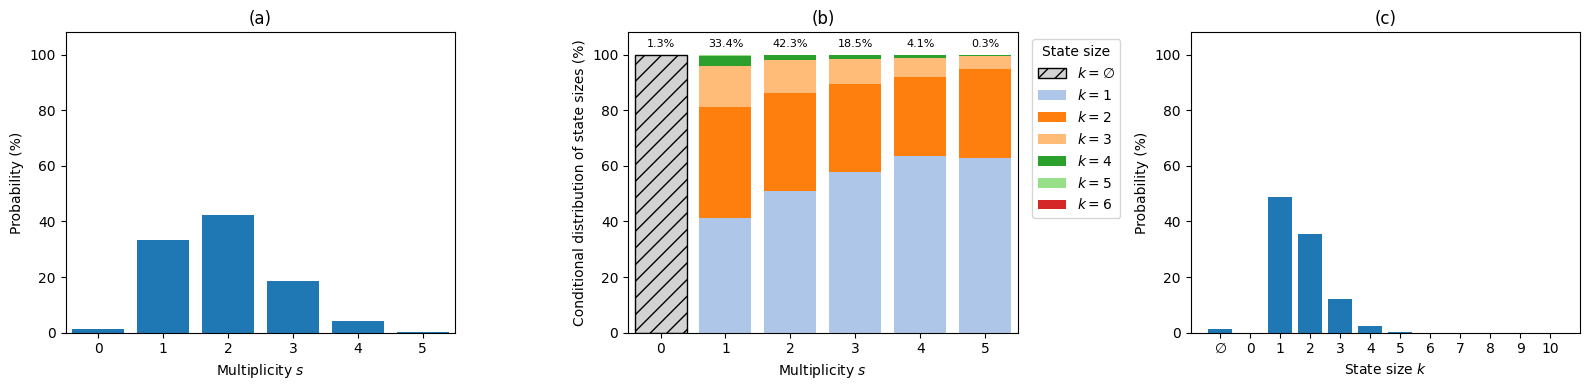

In [16]:
plot_local_summary_glv(
    res_glv_random_pos["random"],
    N=N,
    M=M,
    type_name="stable",
    max_S=5,
    k_min=0,
    include_empty=True
)

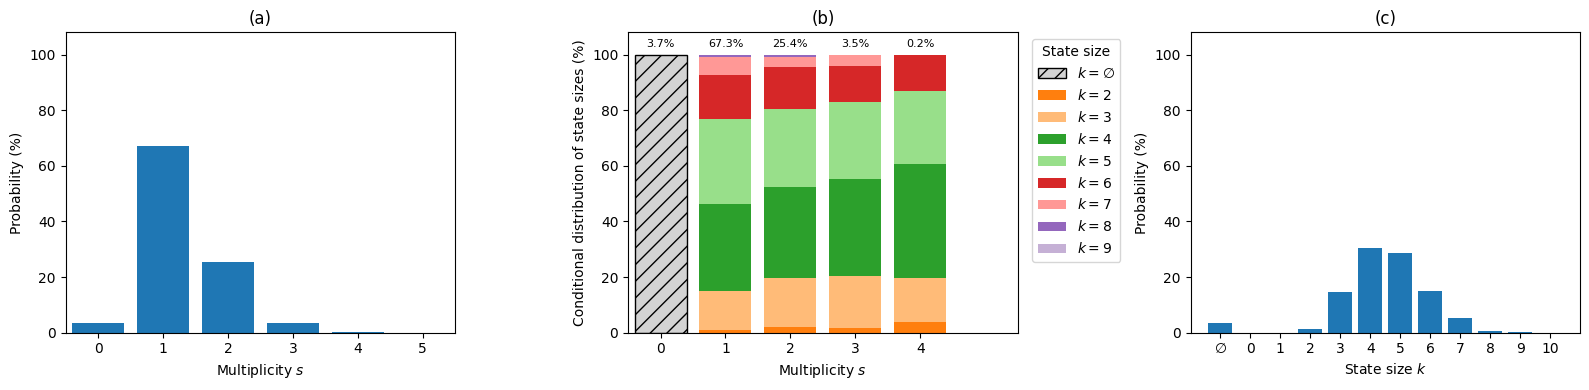

In [17]:
c = 0.90
s = 0.80
plot_local_summary_glv(
    res_grid_all[(c, s)],
    N=N,
    M=M,
    type_name="stable",
    max_S=5,
    k_min=0,
    include_empty=True
)

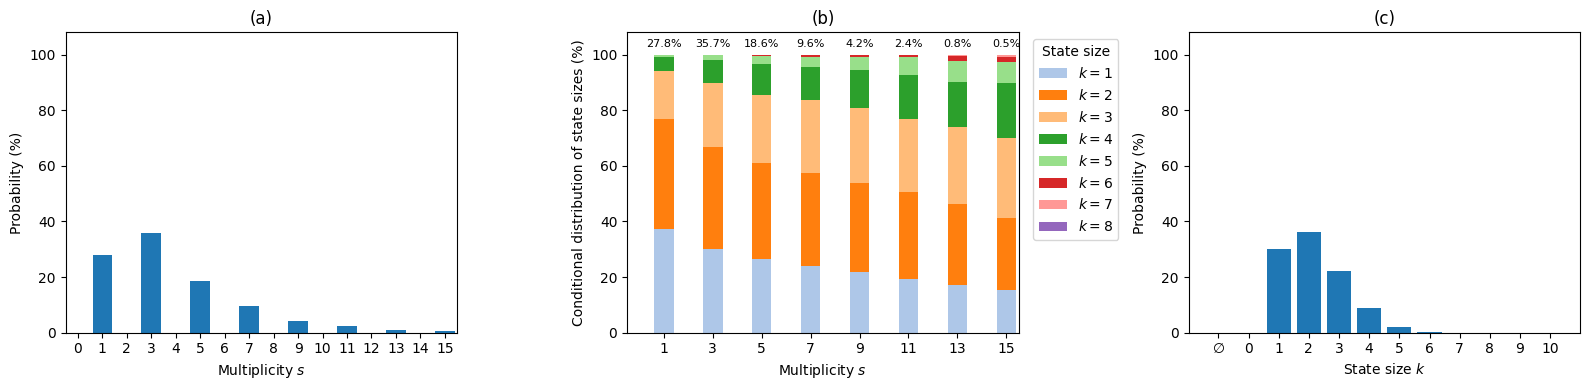

In [18]:
plot_local_summary_glv(
    res_glv_random_pos["random"],
    N=N,
    M=M,
    type_name="saturated",
    max_S=15,
    k_min=0,
    include_empty=True
)

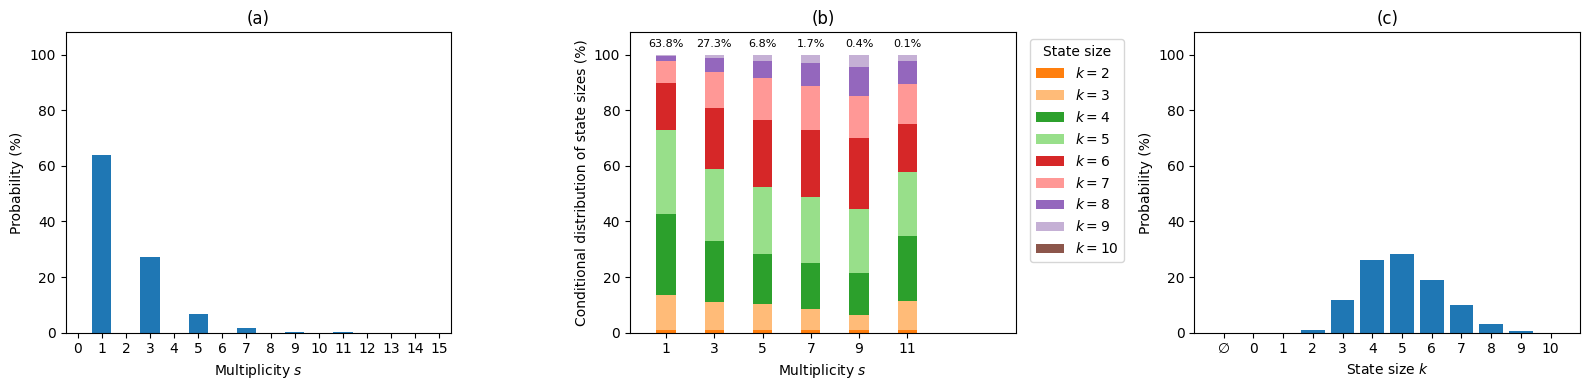

In [19]:
c = 0.90
s = 0.80
plot_local_summary_glv(
    res_grid_all[(c, s)],
    N=N,
    M=M,
    type_name="saturated",
    max_S=15,
    k_min=0,
    include_empty=True
)

In [20]:
def binomial_ci(p, M, z=1.96):
    """
    95% CI for a binomial proportion.
    """
    p = np.asarray(p, dtype=float)
    se = np.sqrt(p * (1 - p) / M)
    low = np.maximum(0, p - z * se)
    high = np.minimum(1, p + z * se)
    return low, high

def plot_none_mono_multi(
    results,
    keys,
    M,
    type_name="stable",
    x_values=None,
    xlabel="",
    title="",
    xscale=None
):
    """
    General function for any model.

    Parameters
    results : results[key]["S"][type_name]
    keys : list of keys used to access results
    M : number of Monte Carlo samples
    x_values : values used on the x-axis
    xlabel : x-axis label
    title : figure title
    xscale : None, "log", or "symlog"
    """
    p_none = []
    p_mono = []
    p_multi = []

    for key in keys:
        S_counter = results[key]["S"][type_name]
        a, b, c = p_none_mono_multi(S_counter, M=M)

        p_none.append(100 * a)
        p_mono.append(100 * b)
        p_multi.append(100 * c)

    if x_values is None:
        x_values = np.arange(len(keys))
    else:
        x_values = np.array(x_values, dtype=float)

    p_none = np.array(p_none)
    p_mono = np.array(p_mono)
    p_multi = np.array(p_multi)

    fig, ax = plt.subplots(figsize=(7, 4))

    # Intersection between P(S=1) and P(S>=2)

    diff = p_mono - p_multi
    intersection_x = None

    for i in range(len(x_values) - 1):
        if diff[i] * diff[i + 1] < 0:
            x1, x2 = x_values[i], x_values[i + 1]
            y1, y2 = diff[i], diff[i + 1]

            intersection_x = x1 - y1 * (x2 - x1) / (y2 - y1)
            break

    # Colored zones
    if intersection_x is not None:
        if diff[0] > 0:
            ax.axvspan(
                min(x_values), intersection_x,
                alpha=0.15, 
                color="orange"
            )
            ax.axvspan(
                intersection_x, max(x_values),
                alpha=0.15,
                color="green"
            )
        else:
            ax.axvspan(
                min(x_values), intersection_x,
                alpha=0.15, 
                color="green"
            )
            ax.axvspan(
                intersection_x, max(x_values),
                alpha=0.15,
                color="orange"

            )

        ax.axvline(
            intersection_x,
            color="black",
            linestyle="--",
            linewidth=1
        )

    # Curves
    ax.plot(x_values, p_none, label=r"$P(S=0)$")
    ax.plot(x_values, p_mono, label=r"$P(S=1)$")
    ax.plot(x_values, p_multi, label=r"$P(S\geq 2)$")

    if xscale == "log":
        ax.set_xscale("log")
    elif xscale == "symlog":
        ax.set_xscale("symlog", linthresh=1e-3)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability (%)")
    ax.set_ylim(-2, 102)
    ax.set_xlim(min(x_values), max(x_values))
    ax.legend()
    ax.grid(alpha=0.25)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [21]:
def plot_none_mono_multi_ci_ax(
    ax,
    results,
    keys,
    M,
    type_name="stable",
    x_values=None,
    xlabel="",
    title="",
    show_ci=True,
    ci_alpha=0.18
):
    p_none = []
    p_mono = []
    p_multi = []

    for key in keys:
        S_counter = results[key]["S"][type_name]
        a, b, c = p_none_mono_multi(S_counter, M=M)

        p_none.append(a)
        p_mono.append(b)
        p_multi.append(c)

    if x_values is None:
        x_values = np.arange(len(keys))
    else:
        x_values = np.array(x_values, dtype=float)

    p_none = np.array(p_none, dtype=float)
    p_mono = np.array(p_mono, dtype=float)
    p_multi = np.array(p_multi, dtype=float)

    none_low, none_high = binomial_ci(p_none, M)
    mono_low, mono_high = binomial_ci(p_mono, M)
    multi_low, multi_high = binomial_ci(p_multi, M)

    p_none_pct = 100 * p_none
    p_mono_pct = 100 * p_mono
    p_multi_pct = 100 * p_multi

    none_low_pct, none_high_pct = 100 * none_low, 100 * none_high
    mono_low_pct, mono_high_pct = 100 * mono_low, 100 * mono_high
    multi_low_pct, multi_high_pct = 100 * multi_low, 100 * multi_high

    diff = p_mono_pct - p_multi_pct
    intersection_x = None

    for i in range(len(x_values) - 1):
        if diff[i] * diff[i + 1] < 0:
            x1, x2 = x_values[i], x_values[i + 1]
            y1, y2 = diff[i], diff[i + 1]
            intersection_x = x1 - y1 * (x2 - x1) / (y2 - y1)
            break

    if intersection_x is not None:
        if diff[0] > 0:
            ax.axvspan(min(x_values), intersection_x, alpha=0.15, color="orange")
            ax.axvspan(intersection_x, max(x_values), alpha=0.15, color="green")
        else:
            ax.axvspan(min(x_values), intersection_x, alpha=0.15, color="green")
            ax.axvspan(intersection_x, max(x_values), alpha=0.15, color="orange")

        ax.axvline(
            intersection_x,
            color="black",
            linestyle="--",
            linewidth=1
        )

    if show_ci:
        ax.fill_between(
            x_values,
            none_low_pct,
            none_high_pct,
            color="gray",
            alpha=ci_alpha,
            label="95% CI"
        )
        ax.fill_between(
            x_values,
            mono_low_pct,
            mono_high_pct,
            color="gray",
            alpha=ci_alpha,
            label="_nolegend_"
        )
        ax.fill_between(
            x_values,
            multi_low_pct,
            multi_high_pct,
            color="gray",
            alpha=ci_alpha,
            label="_nolegend_"
        )

    ax.plot(x_values, p_none_pct, label=r"$P(S=0)$")
    ax.plot(x_values, p_mono_pct, label=r"$P(S=1)$")
    ax.plot(x_values, p_multi_pct, label=r"$P(S\geq 2)$")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability (%)")
    ax.set_ylim(-2, 102)
    ax.set_xlim(min(x_values), max(x_values))
    ax.grid(alpha=0.25)
    ax.set_title(title)

In [22]:
def plot_c05_c09_sigma(
    res_05_sigma,
    res_09_sigma,
    sigma_values,
    M,
    type_name="saturated",
    xlabel=r"Interaction strength $\sigma$"
):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

    plot_none_mono_multi_ci_ax(
        axes[0],
        res_05_sigma,
        keys=sigma_values,
        x_values=sigma_values,
        M=M,
        type_name=type_name,
        xlabel=xlabel,
        title=r"$c=0.5$"
    )

    plot_none_mono_multi_ci_ax(
        axes[1],
        res_09_sigma,
        keys=sigma_values,
        x_values=sigma_values,
        M=M,
        type_name=type_name,
        xlabel=xlabel,
        title=r"$c=0.9$"
    )

    axes[1].set_ylabel("")
    axes[1].legend(loc="best")

    plt.tight_layout()
    plt.show()

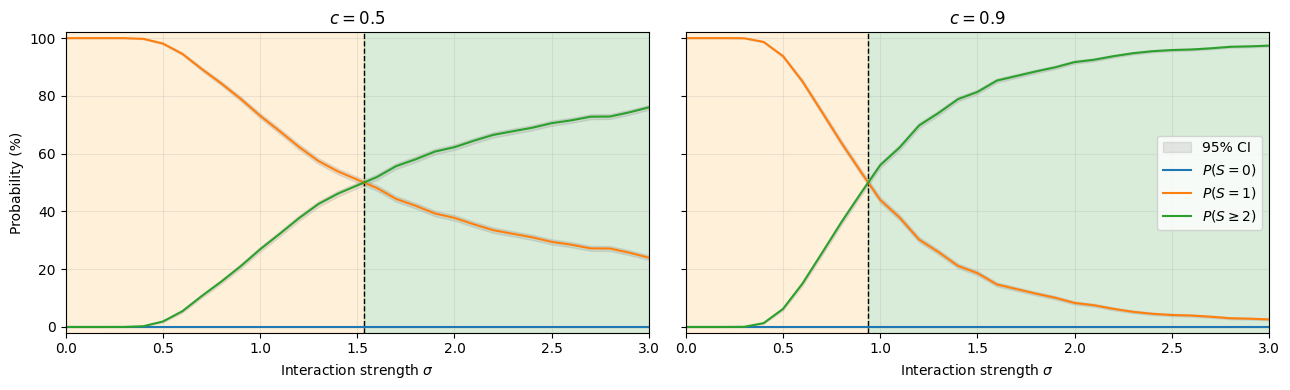

In [23]:
plot_c05_c09_sigma(
    res_05_sigma=res_05_sigma,
    res_09_sigma=res_09_sigma,
    sigma_values=sigma_values,
    M=M,
    type_name="saturated",
    xlabel=r"Interaction strength $\sigma$"
)

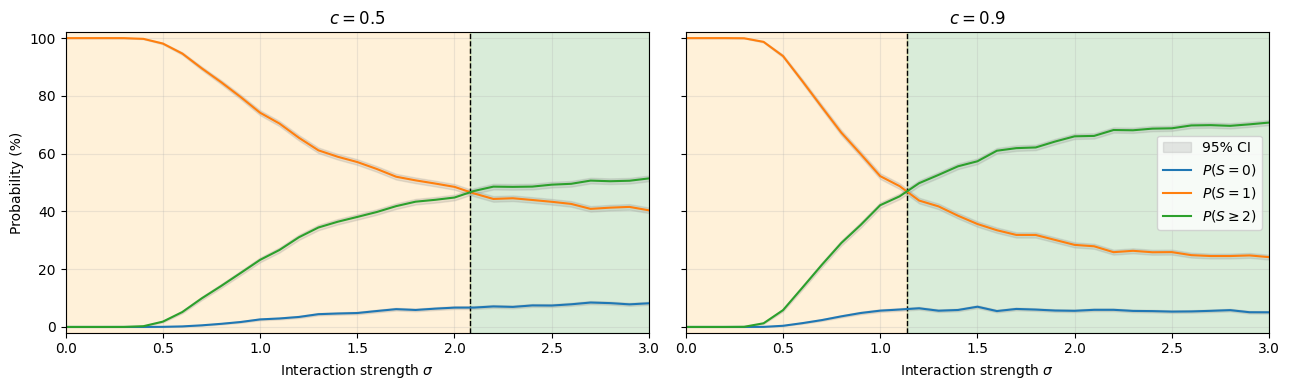

In [24]:
plot_c05_c09_sigma(
    res_05_sigma=res_05_sigma,
    res_09_sigma=res_09_sigma,
    sigma_values=sigma_values,
    M=M,
    type_name="stable",
    xlabel=r"Interaction strength $\sigma$"
)

In [25]:
def plot_expected_glv_sigma_all_c(
    N,
    results_by_c,
    s_values,
    type_name="stable"
):
    s_array = np.array(s_values, dtype=float)

    fig, ax = plt.subplots(figsize=(7, 4))

    markers = {
        0.0: "o",
        0.1: "^",   
        0.3: "s",   
        0.5: "^",   
        0.9: "D",
        1: "^"   
    }

    for c_value, results in results_by_c.items():

        y_system = []

        for s in s_values:
            P = results[s]["P_type"][type_name]
            y_system.append(expected_k_given_nonempty_from_P(P, N=N))

        ax.plot(
            s_array,
            y_system,
            marker=markers.get(c_value, "o"),
            markersize=3,
            linewidth=1,
            label=rf"$c={c_value}$"
        )

    ax.set_ylim(0, N + 0.2)
    ax.set_xlim(min(s_values), max(s_values))

    ax.set_xlabel(r"Interaction strength $\sigma$")
    ax.set_ylabel(r"Expected state size $\mathbb{E}[K^* \mid S>0]$")

    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

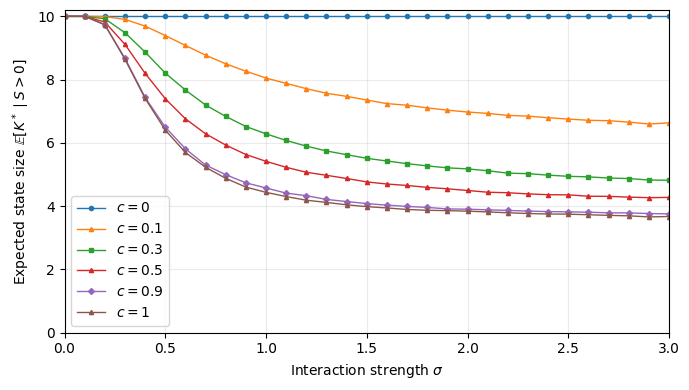

In [26]:
results_by_c = {
    0: res_0_sigma,
    0.1: res_01_sigma,
    0.3: res_03_sigma,
    0.5: res_05_sigma,
    0.9: res_09_sigma,
    1: res_1_sigma

}

plot_expected_glv_sigma_all_c(
    N=10,
    results_by_c=results_by_c,
    s_values=sigma_values,
    type_name="saturated"
)

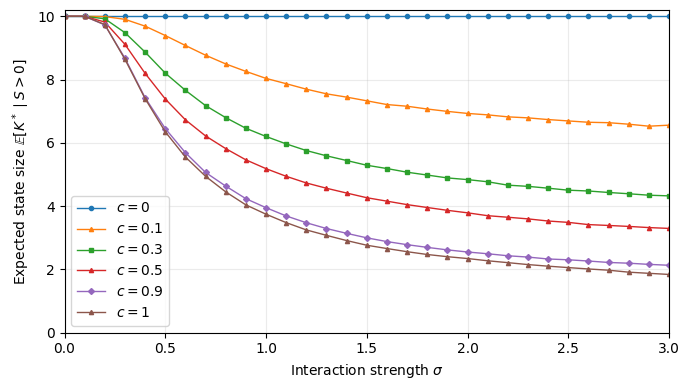

In [27]:
plot_expected_glv_sigma_all_c(
    N=10,
    results_by_c=results_by_c,
    s_values=sigma_values,
    type_name="stable"
)

# Replicator

In [28]:
mu_values = [0, 1e-3, 3e-3, 1e-2, 3e-2, 5e-2, 1e-1, 2e-1, 3e-1, 5e-1, 1, 2, 3, 5, 10, 20, 30, 50, 70, 100] 

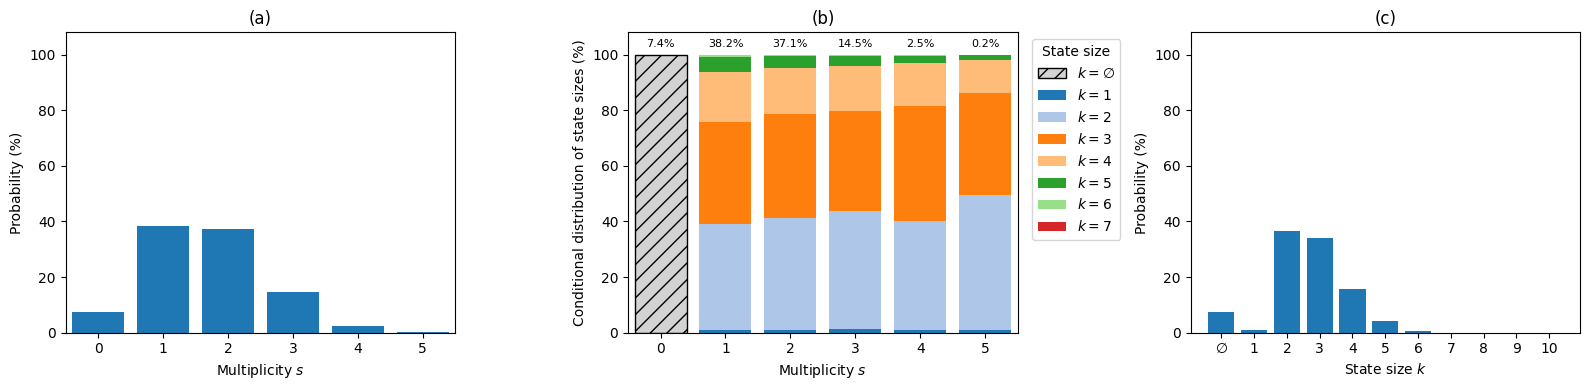

In [29]:
plot_local_summary_glv(
        res_rep_random["random"],
        N=N,
        M=M,
        type_name="stable",
        max_S=5,
        k_min=1,
        include_empty=True
    )

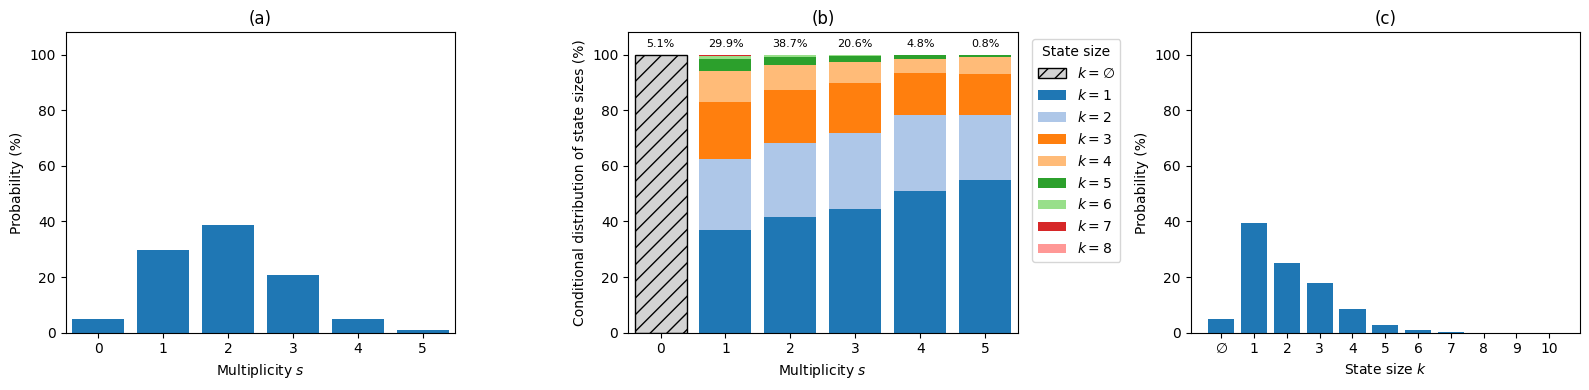

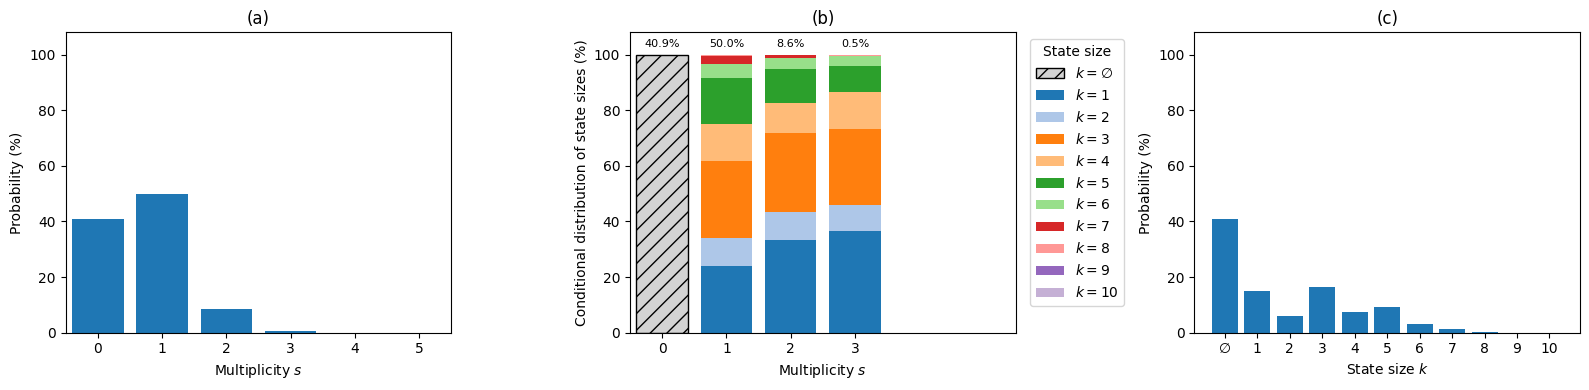

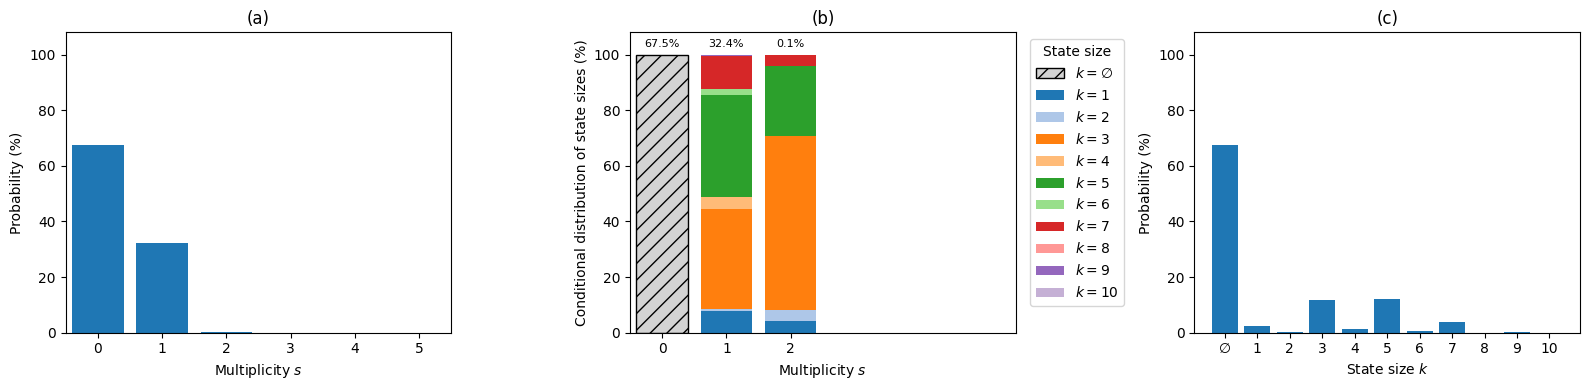

In [30]:
for mu in [1e-1, 1, 10]:
    plot_local_summary_glv(
        res_rep_all[mu],
        N=N,
        M=M,
        type_name="stable",
        max_S=5,
        k_min=1,
        include_empty=True
    )

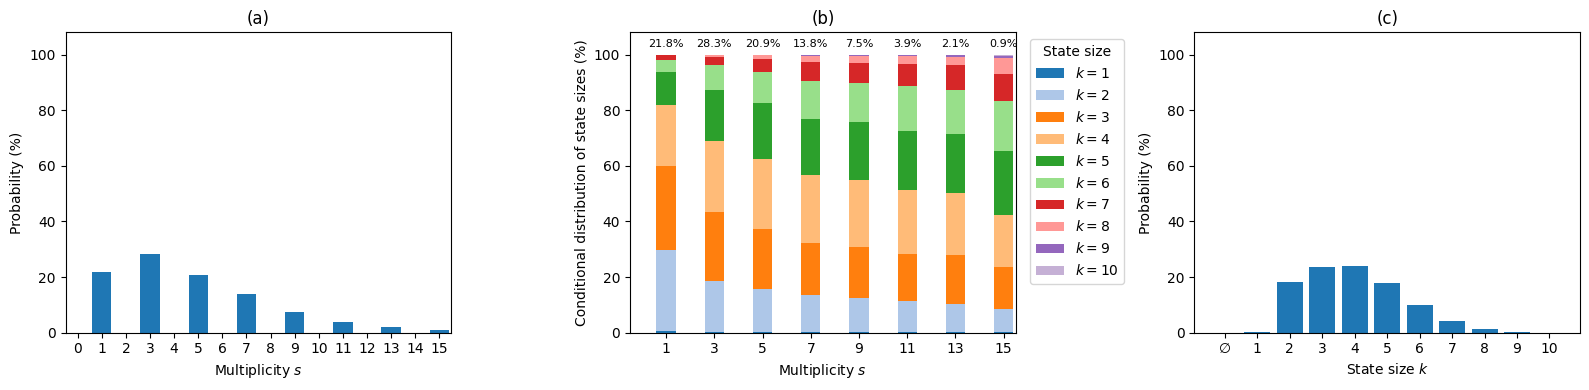

In [31]:
plot_local_summary_glv(
        res_rep_random["random"],
        N=N,
        M=M,
        type_name="saturated",
        max_S=15,
        k_min=1,
        include_empty=True
    )

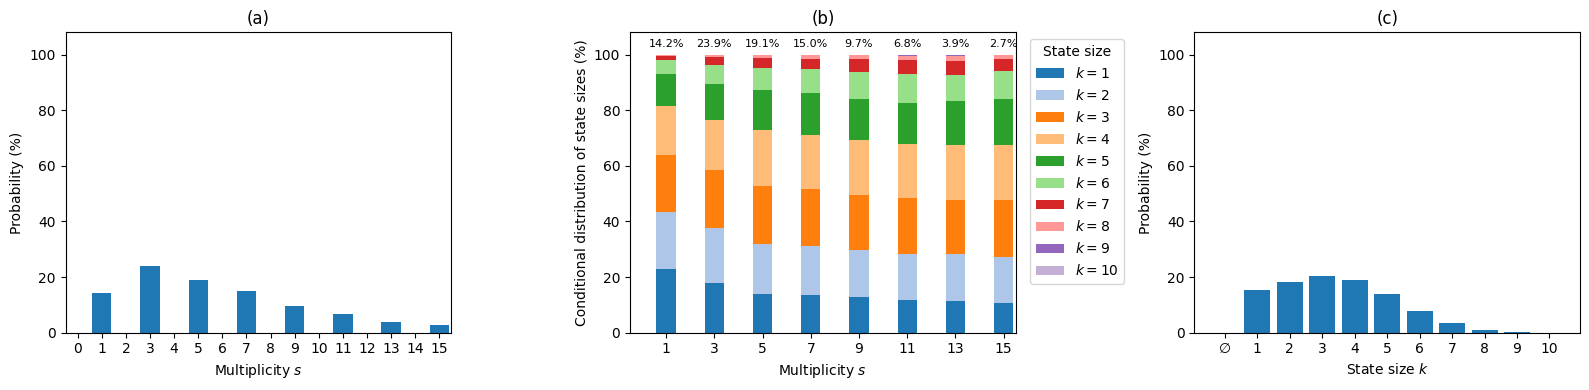

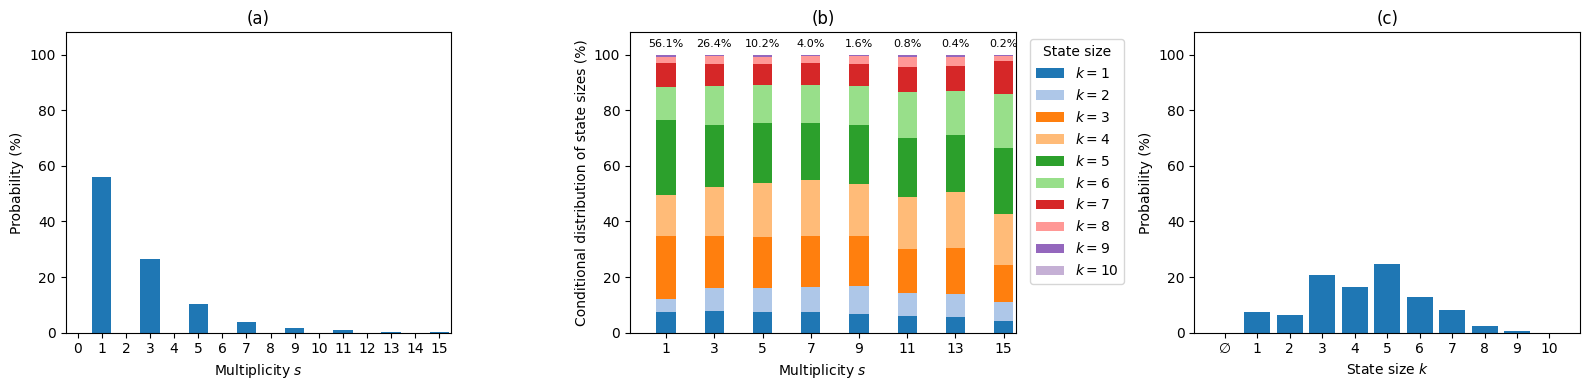

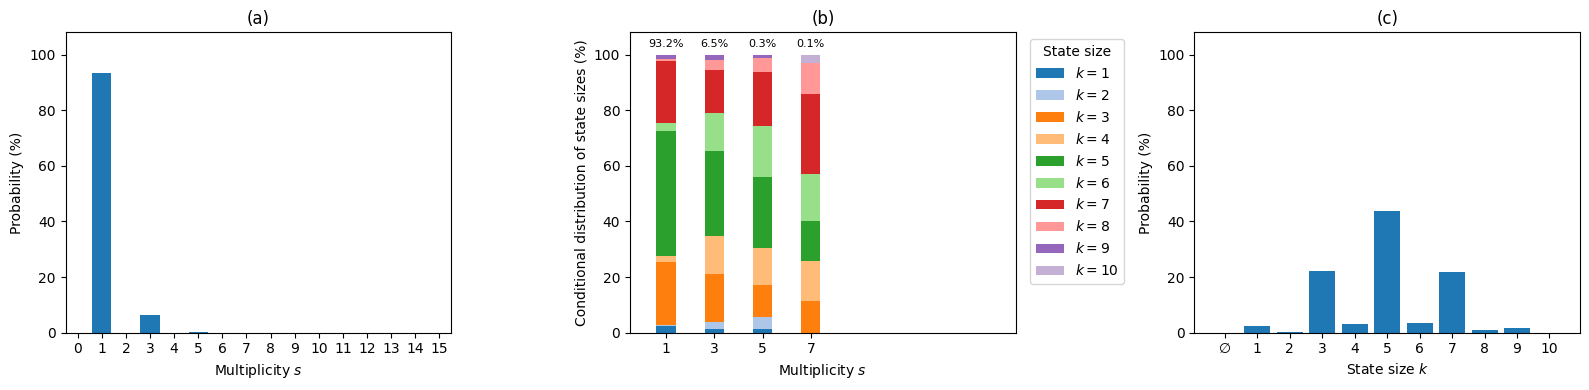

In [32]:
for mu in [1e-1, 1, 10]:
    plot_local_summary_glv(
        res_rep_all[mu],
        N=N,
        M=M,
        type_name="saturated",
        max_S=15,
        k_min=1,
        include_empty=True
    )

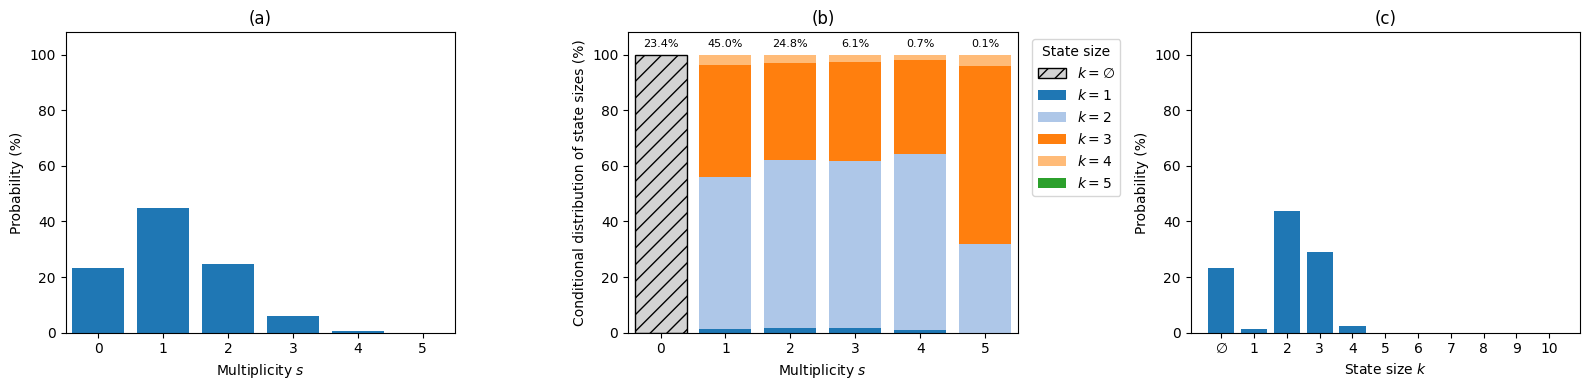

In [33]:
plot_local_summary_glv(
        res_rep_random["random"],
        N=N,
        M=M,
        type_name="ESS",
        max_S=5,
        k_min=1,
        include_empty=True
    )

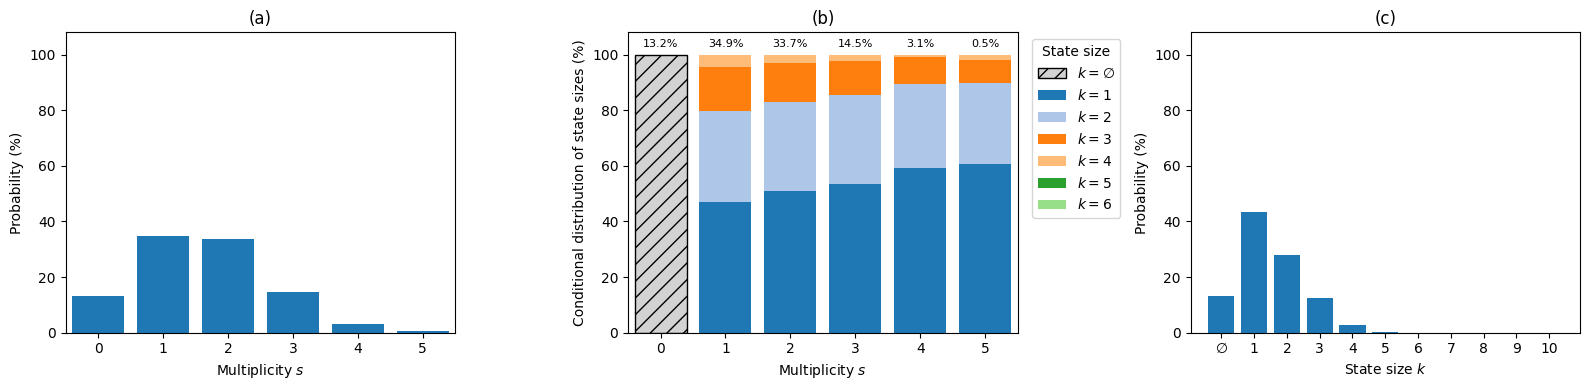

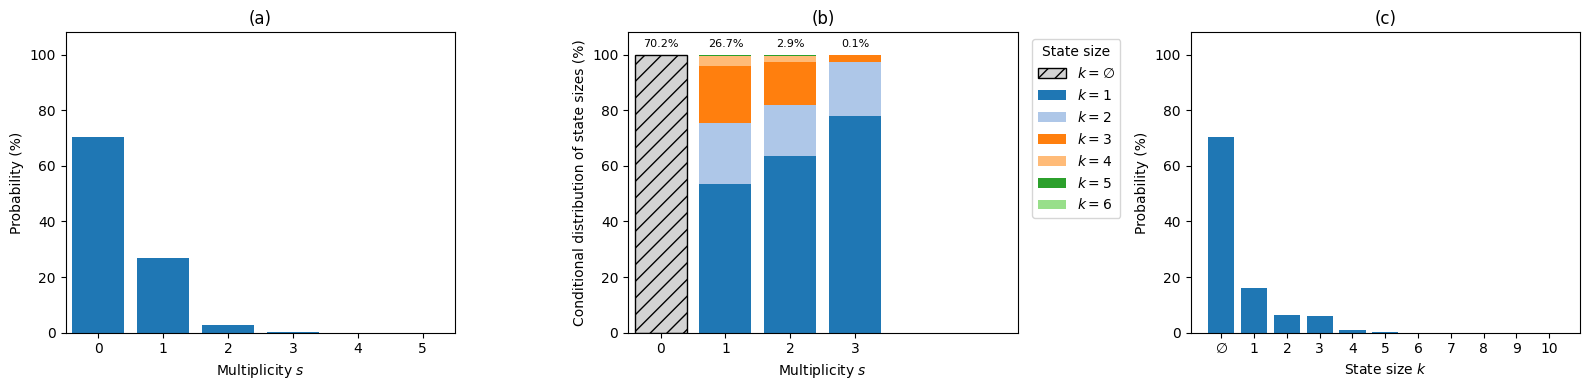

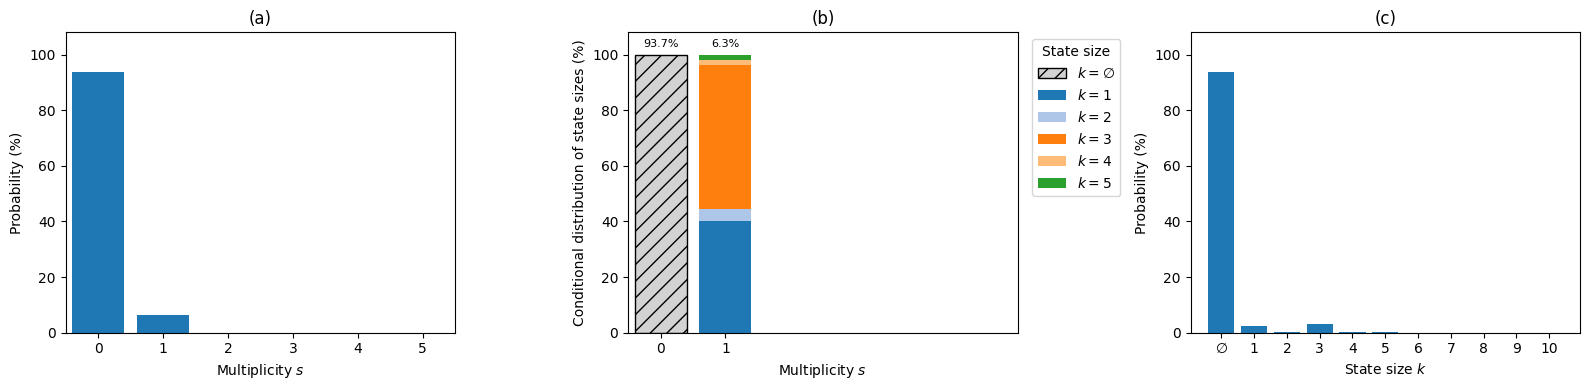

In [34]:
for mu in [1e-1, 1, 10]:
    plot_local_summary_glv(
        res_rep_all[mu],
        N=N,
        M=M,
        type_name="ESS",
        max_S=5,
        k_min=1,
        include_empty=True,
    )

In [35]:
def plot_expected_glv_sigma_rep(
        N, 
        results,
        mu_values, 
        type_name="stable", 
        asymptote=None, 
        transition_region=None
    ):

    y_system = []   

    for s in mu_values:
        P = results[s]["P_type"][type_name]
        y_system.append(expected_k_given_nonempty_from_P(P, N=10))


    s_array = np.array(mu_values, dtype=float)

    plt.figure(figsize=(7, 4))
    if transition_region is not None:
        plt.axvspan(
            transition_region[0],
            transition_region[1],
            alpha=0.12
        )
    if asymptote is not None:
        plt.axhline(
            asymptote,
            linestyle="--",
            linewidth=1, 
            color="black"
        )
    
    
    plt.xscale("symlog", linthresh=1e-3)
    plt.plot(s_array, y_system)
    plt.ylim(0, N + 0.2 )
    plt.xlim(min(mu_values), max(mu_values) )
    plt.xlabel(rf"$\mu$")
    plt.ylabel(r"Expected state size   $\mathbb{E}[K^*\mid S>0]$ ")
    plt.grid(alpha=0.25)
    plt.show()

In [36]:
def plot_combined_mono_multi_expected_mu(
    results,
    keys,
    M,
    N,
    type_name="stable",
    x_values=None,
    linthresh=1e-3
):
    """
    Plot:
    (a) P(S=0), P(S=1), P(S>=2)
    (b) E[K* | S>0]

    The two panels share the same x-axis and the same colored dominance regions.
    """

    # Compute probabilities
    p_none = []
    p_mono = []
    p_multi = []

    for key in keys:
        S_counter = results[key]["S"][type_name]
        a, b, c = p_none_mono_multi(S_counter, M=M)

        p_none.append(100 * a)
        p_mono.append(100 * b)
        p_multi.append(100 * c)

    if x_values is None:
        x_values = np.arange(len(keys), dtype=float)
    else:
        x_values = np.array(x_values, dtype=float)

    p_none = np.array(p_none)
    p_mono = np.array(p_mono)
    p_multi = np.array(p_multi)

    curves = [p_none, p_mono, p_multi]
    labels = [r"$P(S=0)$", r"$P(S=1)$", r"$P(S\geq 2)$"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    # Compute expected state size
    y_expected = []

    for key in keys:
        P = results[key]["P_type"][type_name]
        y_expected.append(expected_k_given_nonempty_from_P(P, N=N))

    y_expected = np.array(y_expected)

    # Intersections between probability curves
    intersections_x = []

    for a in range(3):
        for b in range(a + 1, 3):
            diff = curves[a] - curves[b]

            for i in range(len(x_values) - 1):
                if diff[i] * diff[i + 1] < 0:
                    x1, x2 = x_values[i], x_values[i + 1]
                    y1, y2 = diff[i], diff[i + 1]

                    intersection_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                    intersections_x.append(intersection_x)

    intersections_x = sorted(intersections_x)

    bounds = [min(x_values)] + intersections_x + [max(x_values)]

    dominance_regions = []

    for i in range(len(bounds) - 1):
        x_left = bounds[i]
        x_right = bounds[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        y_mid = [
            np.interp(x_mid, x_values, p_none),
            np.interp(x_mid, x_values, p_mono),
            np.interp(x_mid, x_values, p_multi),
        ]

        dominant = np.argmax(y_mid)
        dominance_regions.append((x_left, x_right, dominant))

    # Plot
    fig, axes = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [1.15, 1]},
        constrained_layout=True
    )

    ax1, ax2 = axes

    for ax in axes:
        for x_left, x_right, dominant in dominance_regions:
            ax.axvspan(
                x_left,
                x_right,
                alpha=0.12,
                color=colors[dominant],
                zorder=0
            )

        for intersection_x in intersections_x:
            ax.axvline(
                intersection_x,
                color="black",
                linestyle="--",
                linewidth=0.9,
                alpha=0.75,
                zorder=1
            )

    # Panel (a): probabilities
    ax1.plot(x_values, p_none, label=labels[0], color=colors[0], linewidth=1.5)
    ax1.plot(x_values, p_mono, label=labels[1], color=colors[1], linewidth=1.5)
    ax1.plot(x_values, p_multi, label=labels[2], color=colors[2], linewidth=1.5)

    ax1.set_ylabel("Probability (%)")
    ax1.set_ylim(-2, 102)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax1.grid(alpha=0.25)

    ax1.text(
        0.02, 0.95,
        "(a)",
        transform=ax1.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # Panel (b): expected state size
    ax2.plot(
        x_values,
        y_expected,
        color="black",
        linewidth=1.5
    )

    ax2.set_ylabel(r"$\mathbb{E}[K^*\mid S>0]$")
    ax2.set_xlabel(r"$\mu$")
    ax2.set_ylim(0, N + 0.2)
    ax2.grid(alpha=0.25)

    ax2.text(
        0.02, 0.95,
        "(b)",
        transform=ax2.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax2.set_xscale("symlog", linthresh=linthresh)
    ax2.set_xlim(min(x_values), max(x_values))


    plt.show()

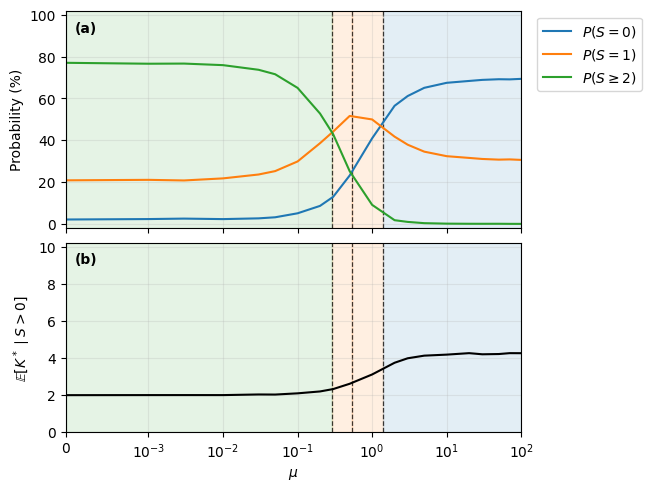

In [37]:
plot_combined_mono_multi_expected_mu(
    results=res_rep_all,
    keys=mu_values,
    M=M,
    N=N,
    type_name="stable",
    x_values=mu_values,
    linthresh=1e-3
)

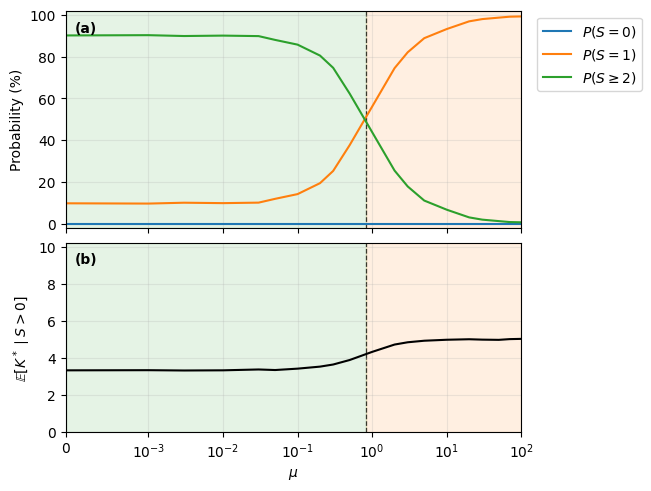

In [38]:
plot_combined_mono_multi_expected_mu(
    results=res_rep_all,
    keys=mu_values,
    M=M,
    N=N,
    type_name="saturated",
    x_values=mu_values,
    linthresh=1e-3
)

In [39]:
def binomial_ci(p, M, z=1.96):
    """
    Normal-approximation 95% CI for a binomial proportion.
    p must be between 0 and 1.
    """
    p = np.asarray(p, dtype=float)
    se = np.sqrt(p * (1 - p) / M)
    low = np.maximum(0, p - z * se)
    high = np.minimum(1, p + z * se)
    return low, high


def plot_combined_mono_multi_expected_mu(
    results,
    keys,
    M,
    N,
    type_name="stable",
    x_values=None,
    linthresh=1e-3,
    show_ci=True,
    z=1.96
):
    """
    Plot:
    (a) P(S=0), P(S=1), P(S>=2)
    (b) E[K* | S>0]

    The two panels share the same x-axis and the same colored dominance regions.
    """

    # Compute probabilities
    p_none = []
    p_mono = []
    p_multi = []

    for key in keys:
        S_counter = results[key]["S"][type_name]
        a, b, c = p_none_mono_multi(S_counter, M=M)

        p_none.append(100 * a)
        p_mono.append(100 * b)
        p_multi.append(100 * c)

    if x_values is None:
        x_values = np.arange(len(keys), dtype=float)
    else:
        x_values = np.array(x_values, dtype=float)

    p_none = np.array(p_none)
    p_mono = np.array(p_mono)
    p_multi = np.array(p_multi)

    # Confidence intervals for probability curves
    none_low, none_high = binomial_ci(p_none / 100, M, z=z)
    mono_low, mono_high = binomial_ci(p_mono / 100, M, z=z)
    multi_low, multi_high = binomial_ci(p_multi / 100, M, z=z)

    none_low = 100 * none_low
    none_high = 100 * none_high

    mono_low = 100 * mono_low
    mono_high = 100 * mono_high

    multi_low = 100 * multi_low
    multi_high = 100 * multi_high

    curves = [p_none, p_mono, p_multi]
    labels = [r"$P(S=0)$", r"$P(S=1)$", r"$P(S\geq 2)$"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    # Compute expected state size
    y_expected = []

    for key in keys:
        P = results[key]["P_type"][type_name]
        y_expected.append(expected_k_given_nonempty_from_P(P, N=N))

    y_expected = np.array(y_expected)

    # Intersections between probability curves
    intersections_x = []

    for a in range(3):
        for b in range(a + 1, 3):
            diff = curves[a] - curves[b]

            for i in range(len(x_values) - 1):
                if diff[i] * diff[i + 1] < 0:
                    x1, x2 = x_values[i], x_values[i + 1]
                    y1, y2 = diff[i], diff[i + 1]

                    intersection_x = x1 - y1 * (x2 - x1) / (y2 - y1)
                    intersections_x.append(intersection_x)

    intersections_x = sorted(intersections_x)

    # Build dominance regions
    bounds = [min(x_values)] + intersections_x + [max(x_values)]

    dominance_regions = []

    for i in range(len(bounds) - 1):
        x_left = bounds[i]
        x_right = bounds[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        y_mid = [
            np.interp(x_mid, x_values, p_none),
            np.interp(x_mid, x_values, p_mono),
            np.interp(x_mid, x_values, p_multi),
        ]

        dominant = np.argmax(y_mid)
        dominance_regions.append((x_left, x_right, dominant))

    # Plot
    fig, axes = plt.subplots(
        2, 1,
        sharex=True,
        constrained_layout=True
    )

    ax1, ax2 = axes

    # Shared colored regions
    for ax in axes:
        for x_left, x_right, dominant in dominance_regions:
            ax.axvspan(
                x_left,
                x_right,
                alpha=0.12,
                color=colors[dominant]
            )

        for intersection_x in intersections_x:
            ax.axvline(
                intersection_x,
                color="black",
                linestyle="--",
                linewidth=1
            )

    # Panel (a): probability confidence intervals
    if show_ci:
        ax1.fill_between(
            x_values,
            none_low,
            none_high,
            color="0.35",
            alpha=0.3,
            label="95% CI"
        )

        ax1.fill_between(
            x_values,
            mono_low,
            mono_high,
            color="gray",
            alpha=0.3,
            label="_nolegend_"
        )

        ax1.fill_between(
            x_values,
            multi_low,
            multi_high,
            color="gray",
            alpha=0.3,
            label="_nolegend_"
        )

    # Panel (a): probabilities
    ax1.plot(x_values, p_none, label=labels[0], color=colors[0], linewidth=1.5, zorder=3)
    ax1.plot(x_values, p_mono, label=labels[1], color=colors[1], linewidth=1.5, zorder=3)
    ax1.plot(x_values, p_multi, label=labels[2], color=colors[2], linewidth=1.5, zorder=3)

    ax1.set_ylabel("Probability (%)")
    ax1.set_ylim(-2, 102)
    ax1.legend(loc="best")
    ax1.grid(alpha=0.25)

    ax1.text(
        0.02, 0.95,
        "(a)",
        transform=ax1.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # Panel (b): expected state size
    ax2.plot(
        x_values,
        y_expected,
        color="black",
        linewidth=1.5
    )

    ax2.set_ylabel(r"$\mathbb{E}[K^*\mid S>0]$")
    ax2.set_xlabel(r"$\mu$")
    ax2.set_ylim(1, 6 + 0.2)
    ax2.grid(alpha=0.25)

    ax2.text(
        0.02, 0.95,
        "(b)",
        transform=ax2.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax2.set_xscale("symlog", linthresh=linthresh)
    ax2.set_xlim(min(x_values), max(x_values))

    plt.show()

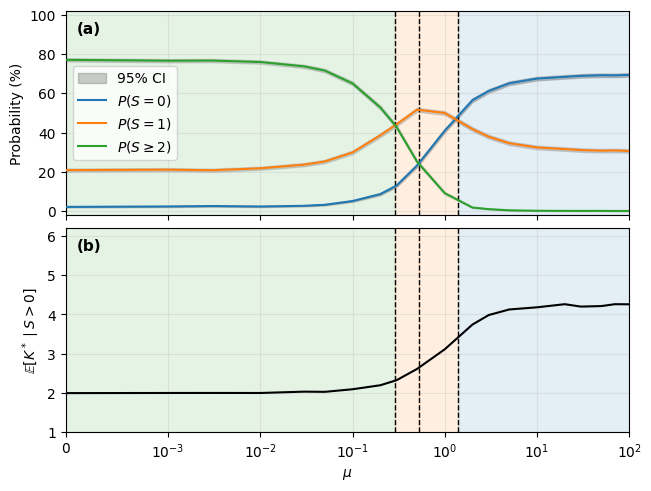

In [40]:
plot_combined_mono_multi_expected_mu(
    results=res_rep_all,
    keys=mu_values,
    x_values=mu_values,
    M=M,
    N=10,
    type_name="stable",
    show_ci=True
)

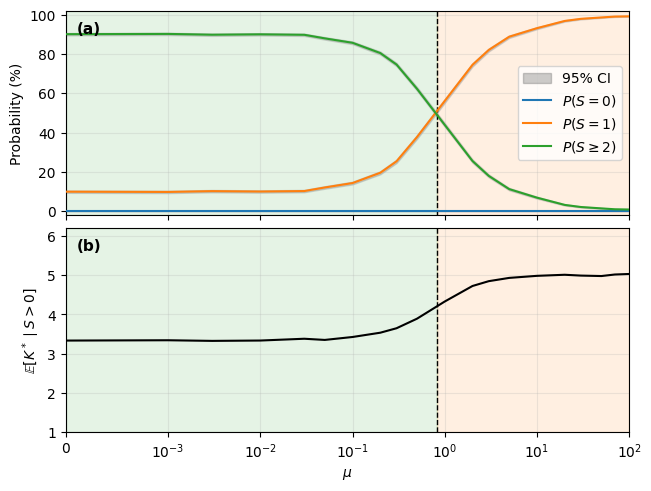

In [41]:
plot_combined_mono_multi_expected_mu(
    results=res_rep_all,
    keys=mu_values,
    x_values=mu_values,
    M=M,
    N=10,
    type_name="saturated",
    show_ci=True
)

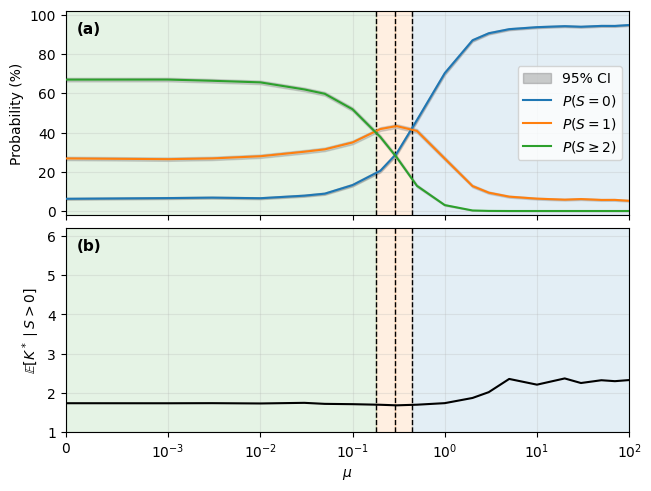

In [42]:
plot_combined_mono_multi_expected_mu(
    results=res_rep_all,
    keys=mu_values,
    x_values=mu_values,
    M=M,
    N=10,
    type_name="ESS",
    show_ci=True
)

In [43]:
def mean_multiplicity_from_counter(S_counter):
    """
    Compute E[S] from a dict storing multiplicity counts.
    eg: S_counter[s]= number of systems with s states.
    """
    total = sum(S_counter.values())

    if total == 0:
        return np.nan

    return sum(s * count for s, count in S_counter.items()) / total


def compute_filtering_proportions_rep(
    results,
    mu_values,
    saturated_name="saturated",
    stable_name="stable",
    ess_name="ESS"
):
    """
    Compute, for each mu:

    - proportion of saturated states that are not stable
       = (E[S_sat] - E[S_stable]) / E[S_sat]

    - proportion of stable states that are not ESS
       = (E[S_stable] - E[S_ESS]) / E[S_stable]
    """

    prop_sat_not_stable = []
    prop_stable_not_ess = []

    mean_sat_list = []
    mean_stable_list = []
    mean_ess_list = []

    for mu in mu_values:
        S_sat = results[mu]["S"][saturated_name]
        S_stable = results[mu]["S"][stable_name]
        S_ess = results[mu]["S"][ess_name]

        mean_sat = mean_multiplicity_from_counter(S_sat)
        mean_stable = mean_multiplicity_from_counter(S_stable)
        mean_ess = mean_multiplicity_from_counter(S_ess)

        mean_sat_list.append(mean_sat)
        mean_stable_list.append(mean_stable)
        mean_ess_list.append(mean_ess)

        if mean_sat > 0:
            prop1 = (mean_sat - mean_stable) / mean_sat
        else:
            prop1 = np.nan

        if mean_stable > 0:
            prop2 = (mean_stable - mean_ess) / mean_stable
        else:
            prop2 = np.nan

        prop_sat_not_stable.append(prop1)
        prop_stable_not_ess.append(prop2)

    return {
        "mu": np.array(mu_values),
        "prop_sat_not_stable": np.array(prop_sat_not_stable),
        "prop_stable_not_ess": np.array(prop_stable_not_ess),
        "mean_sat": np.array(mean_sat_list),
        "mean_stable": np.array(mean_stable_list),
        "mean_ess": np.array(mean_ess_list)
    }

In [44]:
def plot_rep_filtering_proportions(
    results,
    mu_values,
    saturated_name="saturated",
    stable_name="stable",
    ess_name="ESS",
    linthresh=1e-3
):
    
    """
    Plots od proportion of non-stable states among saturated states, and non-ESS among stable states.
    """
    data = compute_filtering_proportions_rep(
        results=results,
        mu_values=mu_values,
        saturated_name=saturated_name,
        stable_name=stable_name,
        ess_name=ess_name
    )

    mu = data["mu"]
    y_sat_not_stable = 100 * data["prop_sat_not_stable"]
    y_stable_not_ess = 100 * data["prop_stable_not_ess"]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(
        mu,
        y_sat_not_stable,
        label=r"Non-stable among saturated states",
        marker="^",
        markersize=4
    )

    ax.plot(
        mu,
        y_stable_not_ess,
        label=r"Non-ESS among stable states",
        marker="D",
        markersize=4
    )

    ax.set_xscale("symlog", linthresh=linthresh) # semi-log scale to handle 0 

    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("Proportion (%)")

    ax.set_ylim(10, 90)
    ax.set_xlim(min(mu), max(mu))

    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()

    plt.show()

    return data

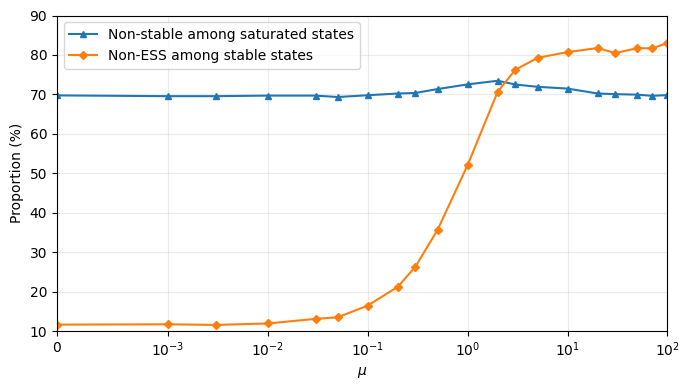

In [45]:
filtering_data = plot_rep_filtering_proportions(
    results=res_rep_all,
    mu_values=mu_values,
    saturated_name="saturated",
    stable_name="stable",
    ess_name="ESS"
)